In [39]:
#Task 1: Web Scraping with BeautifulSoup

## Internship Project

### Objective
#Scrape book details from the "Books to Scrape" website using Python and BeautifulSoup, clean the collected data, perform exploratory data analysis (EDA), and save the dataset in CSV format.

In [2]:
# ==========================================================
# Section 1 : Import Required Libraries
# ==========================================================

import requests
from bs4 import BeautifulSoup
import pandas as pd

In [3]:
# ==========================================================
# Section 2 : Define Website URL & Send HTTP Request
# ==========================================================

url = "https://books.toscrape.com/"

response = requests.get(url)

print("Status Code :", response.status_code)

Status Code : 200


In [4]:
# ==========================================================
# Section 3 : Parse HTML using BeautifulSoup
# ==========================================================

soup = BeautifulSoup(response.text, "html.parser")

print("HTML Parsed Successfully!")

HTML Parsed Successfully!


In [5]:
# ==========================================================
# Section 4 : Inspect the First Book
# ==========================================================

first_book = soup.find("article", class_="product_pod")

print(first_book.prettify())

<article class="product_pod">
 <div class="image_container">
  <a href="catalogue/a-light-in-the-attic_1000/index.html">
   <img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/>
  </a>
 </div>
 <p class="star-rating Three">
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
 </p>
 <h3>
  <a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">
   A Light in the ...
  </a>
 </h3>
 <div class="product_price">
  <p class="price_color">
   Â£51.77
  </p>
  <p class="instock availability">
   <i class="icon-ok">
   </i>
   In stock
  </p>
  <form>
   <button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">
    Add to basket
   </button>
  </form>
 </div>
</article>



In [6]:
# ==========================================================
# Section 5 : Extract Details of the First Book
# ==========================================================

title = first_book.h3.a["title"]
price = first_book.find("p", class_="price_color").text
availability = first_book.find("p", class_="instock availability").text.strip()
rating = first_book.find("p")["class"][1]

print("Title       :", title)
print("Price       :", price)
print("Availability:", availability)
print("Rating      :", rating)

Title       : A Light in the Attic
Price       : Â£51.77
Availability: In stock
Rating      : Three


In [7]:
# ==========================================================
# Section 6 : Extract All Books from the First Page
# ==========================================================

books = []

all_books = soup.find_all("article", class_="product_pod")

for book in all_books:

    title = book.h3.a["title"]

    price = book.find("p", class_="price_color").text

    availability = book.find("p", class_="instock availability").text.strip()

    rating = book.find("p")["class"][1]

    books.append({
        "Title": title,
        "Price": price,
        "Availability": availability,
        "Rating": rating
    })

print("Total Books Scraped:", len(books))

Total Books Scraped: 20


In [8]:
# ==========================================================
# Section 7 : Create DataFrame
# ==========================================================

df = pd.DataFrame(books)

df.head()

,Title,Price,Availability,Rating
0,A Light in the Attic,Â£51.77,In stock,Three
1,Tipping the Velvet,Â£53.74,In stock,One
2,Soumission,Â£50.10,In stock,One
3,Sharp Objects,Â£47.82,In stock,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,In stock,Five


In [9]:
# ==========================================================
# Section 8 : Save Data to CSV
# ==========================================================

df.to_csv("books_data.csv", index=False)

print("CSV file saved successfully!")

CSV file saved successfully!


In [22]:
# ==========================================================
# Section 9 : Scrape All 50 Pages
# ==========================================================

books = []

base_url = "https://books.toscrape.com/catalogue/page-{}.html"

for page in range(1, 51):

    url = base_url.format(page)

    response = requests.get(url)
    
    response.encoding = "utf-8"

    soup = BeautifulSoup(response.text, "html.parser")

    all_books = soup.find_all("article", class_="product_pod")

    for book in all_books:

        title = book.h3.a["title"]

        price = book.find("p", class_="price_color").text

        availability = book.find("p", class_="instock availability").text.strip()

        rating = book.find("p")["class"][1]

        books.append({
            "Title": title,
            "Price": price,
            "Availability": availability,
            "Rating": rating
        })

print(f"Total Books Scraped: {len(books)}")

Total Books Scraped: 1000


In [23]:
# ==========================================================
# Section 10 : Create DataFrame
# ==========================================================

df = pd.DataFrame(books)

print("Shape of Dataset:", df.shape)

df.head()

Shape of Dataset: (1000, 4)


,Title,Price,Availability,Rating
0,A Light in the Attic,£51.77,In stock,Three
1,Tipping the Velvet,£53.74,In stock,One
2,Soumission,£50.10,In stock,One
3,Sharp Objects,£47.82,In stock,Four
4,Sapiens: A Brief History of Humankind,£54.23,In stock,Five


In [24]:
# ==========================================================
# Section 11 : Save Dataset
# ==========================================================

df.to_csv("books_dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [25]:
# ==========================================================
# Section 12 : Display Dataset Information
# ==========================================================

print("First 5 Rows")
display(df.head())

print("\nLast 5 Rows")
display(df.tail())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nDataset Information")
df.info()

First 5 Rows


,Title,Price,Availability,Rating
0,A Light in the Attic,£51.77,In stock,Three
1,Tipping the Velvet,£53.74,In stock,One
2,Soumission,£50.10,In stock,One
3,Sharp Objects,£47.82,In stock,Four
4,Sapiens: A Brief History of Humankind,£54.23,In stock,Five



Last 5 Rows


,Title,Price,Availability,Rating
995,Alice in Wonderland (Alice's Adventures in Won...,£55.53,In stock,One
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",£57.06,In stock,Four
997,A Spy's Devotion (The Regency Spies of London #1),£16.97,In stock,Five
998,1st to Die (Women's Murder Club #1),£53.98,In stock,One
999,"1,000 Places to See Before You Die",£26.08,In stock,Five



Dataset Shape
(1000, 4)

Column Names
Index(['Title', 'Price', 'Availability', 'Rating'], dtype='object')

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         1000 non-null   object
 1   Price         1000 non-null   object
 2   Availability  1000 non-null   object
 3   Rating        1000 non-null   object
dtypes: object(4)
memory usage: 31.4+ KB


In [26]:
# ==========================================================
# Section 13 : Check Missing Values
# ==========================================================

print(df.isnull().sum())

Title           0
Price           0
Availability    0
Rating          0
dtype: int64


In [27]:
# ==========================================================
# Section 14 : Check Duplicate Records
# ==========================================================

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [28]:
# ==========================================================
# Section 15 : Data Cleaning
# ==========================================================

# Remove all non-numeric characters except the decimal point
df["Price"] = df["Price"].str.replace(r"[^0-9.]", "", regex=True)

# Convert to float
df["Price"] = df["Price"].astype(float)

df.head()

,Title,Price,Availability,Rating
0,A Light in the Attic,51.77,In stock,Three
1,Tipping the Velvet,53.74,In stock,One
2,Soumission,50.10,In stock,One
3,Sharp Objects,47.82,In stock,Four
4,Sapiens: A Brief History of Humankind,54.23,In stock,Five


In [29]:
print(df["Price"].head(10).tolist())

[51.77, 53.74, 50.1, 47.82, 54.23, 22.65, 33.34, 17.93, 22.6, 52.15]


In [30]:
# ==========================================================
# Section 16 : Statistical Summary
# ==========================================================

print(df.describe())

            Price
count  1000.00000
mean     35.07035
std      14.44669
min      10.00000
25%      22.10750
50%      35.98000
75%      47.45750
max      59.99000


In [31]:
# ==========================================================
# Section 17 : Import Visualization Library
# ==========================================================

import matplotlib.pyplot as plt

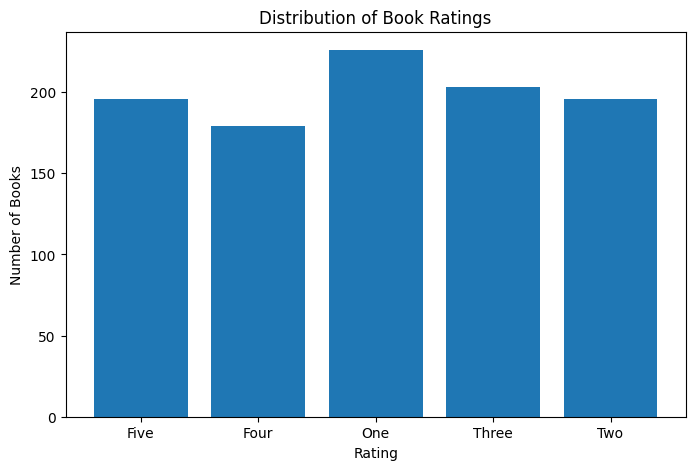

In [32]:
# ==========================================================
# Section 18 : Distribution of Book Ratings
# ==========================================================

rating_counts = df["Rating"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(rating_counts.index, rating_counts.values)

plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.show()

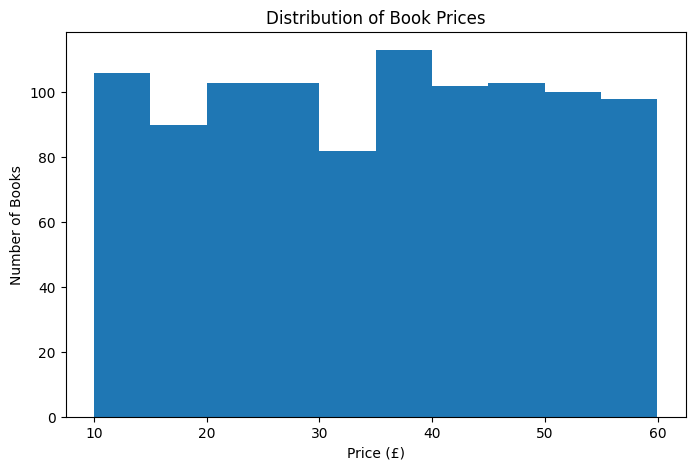

In [33]:
# ==========================================================
# Section 19 : Distribution of Book Prices
# ==========================================================

plt.figure(figsize=(8,5))
plt.hist(df["Price"], bins=10)

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.show()

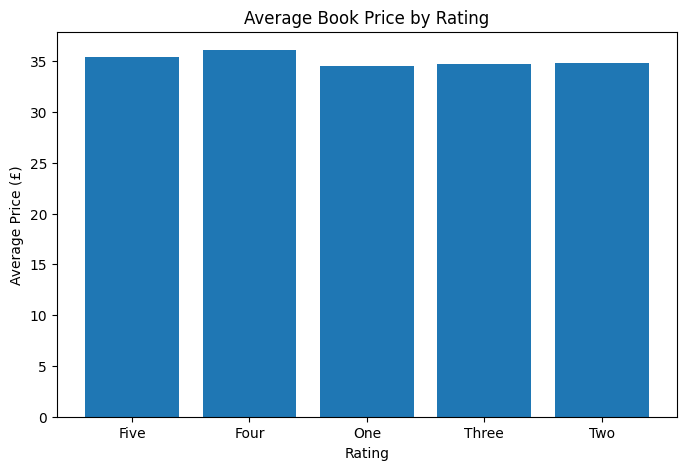

In [34]:
# ==========================================================
# Section 20 : Average Price by Rating
# ==========================================================

avg_price = df.groupby("Rating")["Price"].mean().sort_index()

plt.figure(figsize=(8,5))
plt.bar(avg_price.index, avg_price.values)

plt.title("Average Book Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price (£)")

plt.show()

In [35]:
# ==========================================================
# Section 21 : Key Insights
# ==========================================================

print("Total Books:", len(df))
print("Average Price: £", round(df["Price"].mean(),2))
print("Highest Price: £", df["Price"].max())
print("Lowest Price: £", df["Price"].min())

print("\nBooks by Rating")
print(df["Rating"].value_counts())

Total Books: 1000
Average Price: £ 35.07
Highest Price: £ 59.99
Lowest Price: £ 10.0

Books by Rating
Rating
One      226
Three    203
Five     196
Two      196
Four     179
Name: count, dtype: int64


In [36]:
# ==========================================================
# Section 22 : Save Cleaned Dataset
# ==========================================================

df.to_csv("books_dataset_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [ ]:
# Conclusion

Successfully scraped book information from all 50 pages of the Books to Scrape website.

The project involved:
- Web scraping using Requests and BeautifulSoup
- Data collection from multiple pages
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Data visualization using Matplotlib
- Exporting the cleaned dataset to CSV

This project demonstrates practical skills in Python, web scraping, data preprocessing, and data analysis.